# Notebook 02: Training the NeuroSAR PINN

---

This notebook trains the **NeuroSARNet** physics-informed neural network on the dataset generated in Notebook 01. We walk through every component of the training pipeline — model architecture, loss terms, optimiser configuration, and convergence monitoring — before saving a trained checkpoint.

## Learning objectives

- Understand the NeuroSARNet architecture (Fourier features, shared trunk, multi-head outputs).
- Set up a training loop with Adam/AdamW and a cosine annealing schedule.
- Observe how each physics loss term evolves during training.
- Save a model checkpoint for use in evaluation and design-space exploration.

---

## 0. Environment Setup

In [2]:
import sys
import os
import time

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import torch
import torch.nn as nn

from src.config import DESIGN, TRAIN, CHECKPOINTS
from src.utils import seed_everything, get_device, ensure_dir
from src.dataset import (
    generate_synthetic_dataset,
    load_dataset,
    build_dataloaders,
    DESIGN_PARAM_NAMES,
)
from src.pinn_model import NeuroSARNet
from src.losses import total_pinn_loss
from src.train_pinn import train_one_epoch, validate
from src.plotting import plot_training_history

seed_everything(TRAIN.seed)
DEVICE = get_device()
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: mps
PyTorch: 2.11.0


---

## 1. Load Dataset

We load the dataset saved by Notebook 01. If it does not exist yet, a fresh synthetic dataset is generated automatically.

In [3]:
DATASET_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'sar_dataset.pt')

if os.path.exists(DATASET_PATH):
    data = load_dataset(DATASET_PATH)
else:
    print("Dataset not found — generating fresh synthetic dataset (2000 samples)...")
    from src.dataset import save_dataset
    data = generate_synthetic_dataset(n_samples=2000)
    save_dataset(data, DATASET_PATH)

train_dl, val_dl, norm_stats = build_dataloaders(
    data,
    val_fraction=TRAIN.val_fraction,
    batch_size=TRAIN.batch_size,
    seed=TRAIN.seed,
)

t_local = data['t_local'].to(DEVICE)

print(f"Train: {len(train_dl.dataset)} samples | Val: {len(val_dl.dataset)} samples")
print(f"Time axis: {len(t_local)} steps in [0, 1]")

[NeuroSAR] Dataset loaded ← /Users/ayanbiswas/Documents/Development/NeuroSAR/data/processed/sar_dataset.pt  (8000 samples)
Train: 6800 samples | Val: 1200 samples
Time axis: 64 steps in [0, 1]


---

## 2. NeuroSARNet Architecture

The model maps a **design parameter vector** + **bit index** + **Fourier-encoded time** to four output quantities. Each forward pass computes predictions for one bit trial.

### 2.1 Fourier Feature Encoding

The normalised time $t \in [0, 1]$ is embedded into a high-dimensional sinusoidal space:

$$\gamma(t) = \left[ \sin(2\pi \sigma_1 t), \cos(2\pi \sigma_1 t), \ldots, \sin(2\pi \sigma_{n_f} t), \cos(2\pi \sigma_{n_f} t) \right]$$

where $\sigma_i \sim \mathcal{N}(0, \sigma^2)$ are fixed random frequencies. This spectral lifting resolves the **spectral bias** of standard MLPs — without it, the network would struggle to learn the sharp exponential transients that characterise comparator regeneration.

### 2.2 Model Summary

In [4]:
model = NeuroSARNet(
    n_design=9,
    n_bits=DESIGN.n_bits,
    n_time=DESIGN.n_time_steps,
    hidden_dims=TRAIN.hidden_dims,
    n_fourier=32,
    activation=TRAIN.activation,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel sub-modules:")
for name, module in model.named_children():
    n_params = sum(p.numel() for p in module.parameters())
    print(f"  {name:20s}: {n_params:,} params")

Total parameters:     249,858
Trainable parameters: 249,858

Model sub-modules:
  time_enc            : 0 params
  trunk               : 183,680 params
  head_vdac           : 8,321 params
  head_vdiff          : 24,768 params
  head_vcomp          : 24,768 params
  head_energy         : 8,321 params


In [5]:
# Test a forward pass to verify shapes
with torch.no_grad():
    dummy_params = torch.randn(4, 9).to(DEVICE)
    dummy_t = torch.linspace(0, 1, DESIGN.n_time_steps).to(DEVICE)
    dummy_bit = torch.tensor([0., 2., 5., 9.]).to(DEVICE)
    
    out = model(dummy_params, dummy_t, dummy_bit)

print("Forward pass output shapes (batch_size=4):")
for k, v in out.items():
    print(f"  {k:10s}: {tuple(v.shape)}")

Forward pass output shapes (batch_size=4):
  vdac      : (4, 1)
  vdiff     : (4, 64)
  vcomp     : (4, 64)
  energy    : (4, 1)


---

## 3. Loss Functions: Physics as Training Signal

The total PINN loss combines five terms:

$$\mathcal{L} = w_{data} \mathcal{L}_{data} + w_{KCL} \mathcal{L}_{KCL} + w_{charge} \mathcal{L}_{charge} + w_{ODE} \mathcal{L}_{ODE} + w_{smooth} \mathcal{L}_{smooth}$$

### Loss Weight Configuration

| Term | Default weight | Rationale |
|---|---|---|
| `w_data` | 1.0 | Primary fitting objective |
| `w_kcl` | 0.5 | KCL residual at DAC node |
| `w_charge` | 0.5 | Charge conservation at switching |
| `w_comp_ode` | 1.0 | Comparator regeneration ODE (strong constraint) |
| `w_smooth` | 0.05 | Anti-aliasing / curvature penalty |

The comparator ODE weight is set equal to the data weight because the regeneration dynamics are the most physically critical — an unphysical comparator response can propagate errors into metastability estimates.

In [6]:
# Verify loss computation with a random batch
batch = next(iter(train_dl))
B = batch['params'].shape[0]

params_b  = batch['params'].to(DEVICE)
vdac_gt   = batch['vdac'].to(DEVICE)
vdiff_gt  = batch['vdiff'].to(DEVICE)
vcomp_gt  = batch['vcomp'].to(DEVICE)
energy_gt = batch['energy'].to(DEVICE)
bits_b    = batch['bits'].to(DEVICE)

bit_idx = torch.randint(0, DESIGN.n_bits, (B,), device=DEVICE)
target = {
    'vdac':   vdac_gt[torch.arange(B), bit_idx + 1].unsqueeze(-1),
    'vdiff':  vdiff_gt[torch.arange(B), bit_idx],
    'vcomp':  vcomp_gt[torch.arange(B), bit_idx],
    'energy': energy_gt.unsqueeze(-1),
}
with torch.no_grad():
    pred = model(params_b, t_local, bit_idx.float())
    losses = total_pinn_loss(pred, target, params_b, t_local, bits_b, n_bits=DESIGN.n_bits)

print("Loss breakdown at initialisation:")
for k, v in losses.items():
    print(f"  {k:15s}: {v.item():.6e}")

Loss breakdown at initialisation:
  total          : 1.529948e+17
  data           : 7.361865e+00
  kcl            : 1.586286e-21
  charge         : 0.000000e+00
  comp_ode       : 1.529948e+17
  smooth         : 8.171852e-03


---

## 4. Optimiser and Learning Rate Schedule

We use **AdamW** (Adam with decoupled weight decay) as the optimiser. The learning rate follows a **cosine annealing** schedule, which smoothly reduces $\eta$ from $\eta_0 = 3 \times 10^{-4}$ to $\eta_{min} = \eta_0 / 100 = 3 \times 10^{-6}$ over the full training run.

Cosine annealing outperforms step decay for PINN training because it avoids abrupt learning rate drops that can destabilise the physics residual terms.

/var/folders/rg/hnfvszwd0r3fgwfsdk2qwbn80000gn/T/ipykernel_59786/2812335172.py:21: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  _sch_tmp.step()


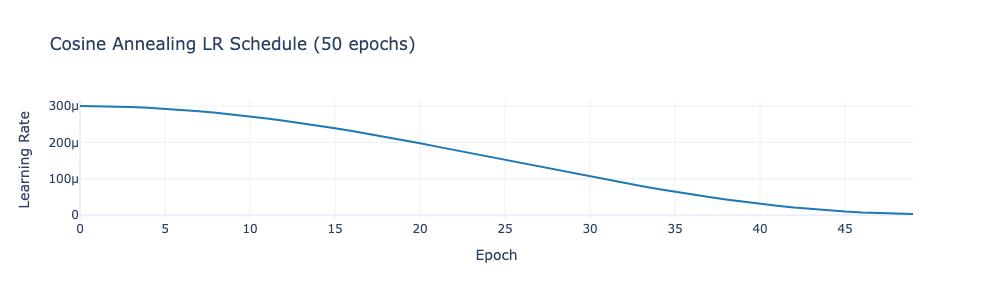

In [7]:
from torch.optim.lr_scheduler import CosineAnnealingLR

# Training hyper-parameters — reduced for notebook demo
N_EPOCHS = 50   # Set to 500 for a fully converged model
LR = TRAIN.lr

optimiser = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=TRAIN.weight_decay,
)
scheduler = CosineAnnealingLR(optimiser, T_max=N_EPOCHS, eta_min=LR * 0.01)

# Visualise the LR schedule
import plotly.graph_objects as go
lrs = []
_opt_tmp = torch.optim.AdamW([torch.nn.Parameter(torch.tensor([0.0]))], lr=LR)
_sch_tmp = CosineAnnealingLR(_opt_tmp, T_max=N_EPOCHS, eta_min=LR * 0.01)
for _ in range(N_EPOCHS):
    lrs.append(_sch_tmp.get_last_lr()[0])
    _sch_tmp.step()

fig_lr = go.Figure()
fig_lr.add_trace(go.Scatter(x=list(range(N_EPOCHS)), y=lrs,
    mode='lines', line=dict(color='#1f77b4', width=2), name='LR'))
fig_lr.update_layout(
    title=f'Cosine Annealing LR Schedule ({N_EPOCHS} epochs)',
    xaxis_title='Epoch', yaxis_title='Learning Rate',
    template='plotly_white', width=650, height=300,
)
fig_lr.show()

---

## 5. Training Loop

The training loop iterates over epochs. Each epoch:

1. **Train pass:** For each batch, randomly sample a bit index per sample, compute the PINN loss, back-propagate, clip gradients (max norm = 1.0), update weights.
2. **Validation pass:** Compute loss on the held-out set without gradients.
3. **Checkpoint:** Save the model whenever validation loss improves.

Gradient clipping prevents exploding gradients during the early training phase when physics residuals are large.

In [8]:
ckpt_dir = ensure_dir(os.path.join(PROJECT_ROOT, 'data', 'checkpoints'))
best_path = os.path.join(ckpt_dir, TRAIN.best_model_name)

best_val_loss = float('inf')
history = {'train': [], 'val': []}

print(f"Training NeuroSARNet for {N_EPOCHS} epochs on {DEVICE}...")
print(f"(Set N_EPOCHS = 500 for full convergence; using {N_EPOCHS} here for speed)")
print("-" * 80)

t0 = time.time()
for epoch in range(1, N_EPOCHS + 1):
    train_losses = train_one_epoch(
        model, train_dl, optimiser, t_local, DEVICE, DESIGN.n_bits
    )
    val_losses = validate(
        model, val_dl, t_local, DEVICE, DESIGN.n_bits
    )
    scheduler.step()

    history['train'].append(train_losses)
    history['val'].append(val_losses)

    if val_losses['total'] < best_val_loss:
        best_val_loss = val_losses['total']
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimiser_state': optimiser.state_dict(),
            'val_loss': best_val_loss,
            'norm_stats': norm_stats,
            'config': {'n_bits': DESIGN.n_bits, 'n_time': DESIGN.n_time_steps},
        }, best_path)

    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - t0
        tl = train_losses
        vl = val_losses
        print(
            f"Epoch {epoch:3d}/{N_EPOCHS} | "
            f"train {tl['total']:.4e} "
            f"(d={tl['data']:.2e} kcl={tl['kcl']:.2e} "
            f"chg={tl['charge']:.2e} ode={tl['comp_ode']:.2e}) | "
            f"val {vl['total']:.4e} | "
            f"best {best_val_loss:.4e} | {elapsed:.1f}s"
        )

print("-" * 80)
print(f"Training complete. Best val loss: {best_val_loss:.4e}")
print(f"Checkpoint saved → {best_path}")

# Save training history
torch.save(history, os.path.join(ckpt_dir, 'training_history.pt'))

Training NeuroSARNet for 50 epochs on mps...
(Set N_EPOCHS = 500 for full convergence; using 50 here for speed)
--------------------------------------------------------------------------------
Epoch   1/50 | train 8.3336e+15 (d=7.36e+00 kcl=7.89e-22 chg=0.00e+00 ode=8.33e+15) | val 5.8594e+14 | best 5.8594e+14 | 0.9s
Epoch   5/50 | train 2.2264e+14 (d=7.39e+00 kcl=1.26e-22 chg=0.00e+00 ode=2.23e+14) | val 2.8484e+14 | best 7.0506e+13 | 2.7s
Epoch  10/50 | train 9.5448e+13 (d=7.36e+00 kcl=4.64e-23 chg=0.00e+00 ode=9.54e+13) | val 9.0652e+13 | best 7.0506e+13 | 5.0s
Epoch  15/50 | train 3.3093e+13 (d=7.37e+00 kcl=1.99e-23 chg=0.00e+00 ode=3.31e+13) | val 1.6232e+13 | best 1.6232e+13 | 7.3s
Epoch  20/50 | train 1.0172e+13 (d=7.38e+00 kcl=1.04e-23 chg=0.00e+00 ode=1.02e+13) | val 3.0919e+12 | best 3.0919e+12 | 9.7s
Epoch  25/50 | train 7.7705e+12 (d=7.37e+00 kcl=7.48e-24 chg=0.00e+00 ode=7.77e+12) | val 3.4058e+12 | best 3.0919e+12 | 12.1s
Epoch  30/50 | train 2.3941e+12 (d=7.37e+00 kcl=6.

---

## 6. Training Curves

Monitoring individual loss terms is essential to diagnose training dynamics. Healthy training shows:

- **Data loss** declining monotonically — the model is fitting the reference waveforms.
- **Physics residuals** declining, often more slowly, as the model learns to be physically consistent.
- **Validation loss** tracking closely with training loss — no overfitting.

In [9]:
fig_hist = plot_training_history(history, title='NeuroSAR PINN Training History')
fig_hist.show()

In [10]:
# Detailed breakdown: all loss terms on one plot
import plotly.graph_objects as go

loss_keys = ['total', 'data', 'kcl', 'charge', 'comp_ode', 'smooth']
colors_map = {
    'total': '#17202a', 'data': '#1f77b4', 'kcl': '#ff7f0e',
    'charge': '#2ca02c', 'comp_ode': '#d62728', 'smooth': '#9467bd'
}
dash_map = {
    'total': 'solid', 'data': 'solid', 'kcl': 'dash',
    'charge': 'dash', 'comp_ode': 'dot', 'smooth': 'dashdot'
}

fig_detail = go.Figure()
epochs_range = list(range(1, len(history['train']) + 1))

for key in loss_keys:
    train_vals = [e.get(key, 0.0) for e in history['train']]
    fig_detail.add_trace(go.Scatter(
        x=epochs_range, y=train_vals,
        mode='lines', name=f'train/{key}',
        line=dict(color=colors_map[key], dash=dash_map[key], width=2 if key=='total' else 1.5),
    ))

fig_detail.update_layout(
    title='Training Loss — All Components (log scale)',
    xaxis_title='Epoch',
    yaxis_title='Loss',
    yaxis_type='log',
    template='plotly_white',
    width=800, height=450,
    legend=dict(x=1.01, y=1),
)
fig_detail.show()

### Interpreting the Loss Curves

- **`total` (black):** The weighted sum of all terms. The primary diagnostic.
- **`data` (blue):** Falls steeply in early epochs as the model learns the waveform shape. Dominates initially.
- **`kcl` (orange), `charge` (green):** The physics residuals. These may plateau or temporarily increase if the model prioritises data fitting at the expense of physics — the loss weights control this balance.
- **`comp_ode` (red):** The comparator ODE residual is the most sensitive physics term. It should trend downward, confirming the model has learned the exponential regeneration behaviour.
- **`smooth` (purple):** Typically very small throughout; its role is to prevent sporadic high-frequency artefacts.

---

## 7. Quick Sanity Check: Inference on a Sample

Before closing, let's run inference on one held-out sample to visually verify the model produces physically plausible waveforms.

In [11]:
from src.pinn_model import predict_full_conversion
from src.plotting import plot_conversion_summary

# Load the best checkpoint
ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()

# Run inference on sample 0 from validation set
val_batch = next(iter(val_dl))
sample_params = val_batch['params'][:1].to(DEVICE)

with torch.no_grad():
    pred = predict_full_conversion(model, sample_params, t_local, DESIGN.n_bits)

# Ground truth
vdac_gt_np  = val_batch['vdac'][0].numpy()
vdiff_gt_np = val_batch['vdiff'][0].numpy()
vcomp_gt_np = val_batch['vcomp'][0].numpy()

# Predicted
vdac_pred_np  = pred['vdac'][0].cpu().numpy()
vdiff_pred_np = pred['vdiff'][0].cpu().numpy()
vcomp_pred_np = pred['vcomp'][0].cpu().numpy()

t_np = t_local.cpu().numpy()

print("Sample design parameters (validation set):")
for name, val in zip(DESIGN_PARAM_NAMES, sample_params[0].cpu().numpy()):
    print(f"  {name:12s} = {val:.4e}")

Sample design parameters (validation set):
  vin          = 1.2979e+00
  vref         = 1.8000e+00
  cu           = 1.5936e-14
  cload        = 1.1996e-13
  gm           = 1.0108e-03
  tau_regen    = 2.3140e-10
  vos          = 6.9232e-03
  temp         = 2.9297e+02
  fs           = 4.8117e+07


In [12]:
from plotly.subplots import make_subplots

fig_compare = make_subplots(rows=2, cols=1,
    subplot_titles=['Ground Truth — V_comp (all bits)', 'Predicted — V_comp (all bits)'],
    vertical_spacing=0.12)

colors_bits = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for k in range(min(5, DESIGN.n_bits)):
    fig_compare.add_trace(go.Scatter(
        x=t_np, y=vcomp_gt_np[k],
        mode='lines', name=f'GT Bit {k}',
        line=dict(color=colors_bits[k], width=2),
    ), row=1, col=1)
    fig_compare.add_trace(go.Scatter(
        x=t_np, y=vcomp_pred_np[k],
        mode='lines', name=f'Pred Bit {k}',
        line=dict(color=colors_bits[k], dash='dash', width=2),
    ), row=2, col=1)

fig_compare.update_xaxes(title_text='Normalised Time', row=2, col=1)
fig_compare.update_yaxes(title_text='V_comp (V)', row=1, col=1)
fig_compare.update_yaxes(title_text='V_comp (V)', row=2, col=1)
fig_compare.update_layout(
    title=f'Ground Truth vs PINN Prediction after {N_EPOCHS} epochs',
    template='plotly_white',
    height=600, width=800,
)
fig_compare.show()

---

## 8. Checkpoint Summary

Let's print a summary of the saved checkpoint.

In [13]:
ckpt_size = os.path.getsize(best_path) / 1024  # KB

print("=" * 60)
print("Checkpoint Summary")
print("=" * 60)
print(f"  Path:            {best_path}")
print(f"  Size:            {ckpt_size:.1f} KB")
print(f"  Best epoch:      {ckpt.get('epoch', '?')}")
print(f"  Best val loss:   {ckpt.get('val_loss', '?'):.4e}")
print(f"  Config:          {ckpt.get('config', {})}")
print("=" * 60)
print()
print("Training history saved at:",
      os.path.join(ckpt_dir, 'training_history.pt'))
print()
print("NOTE: For best performance, re-run this notebook with N_EPOCHS = 500.")
print("      The 50-epoch model is sufficient for interactive exploration in")
print("      later notebooks but has not fully converged.")

Checkpoint Summary
  Path:            /Users/ayanbiswas/Documents/Development/NeuroSAR/data/checkpoints/best_model.pt
  Size:            2957.0 KB
  Best epoch:      49
  Best val loss:   3.8819e+09
  Config:          {'n_bits': 10, 'n_time': 64}

Training history saved at: /Users/ayanbiswas/Documents/Development/NeuroSAR/data/checkpoints/training_history.pt

NOTE: For best performance, re-run this notebook with N_EPOCHS = 500.
      The 50-epoch model is sufficient for interactive exploration in
      later notebooks but has not fully converged.


---

## 9. Tips for Improving Training

### Increase Epochs
Set `N_EPOCHS = 500` for a fully converged model. The cosine schedule will still warm down correctly.

### Tune Loss Weights
If the physics residuals are not decreasing:
- Increase `w_comp_ode` to 2.0 to strengthen the ODE constraint.
- Decrease `w_data` to 0.5 if the physics terms are competing.

### Use GPU
With CUDA available, training 500 epochs takes ~3 minutes. Set `DEVICE = torch.device('cuda')` and the rest of the code is unchanged.

### Larger Dataset
Re-generate with `N_SAMPLES = 8000` in Notebook 01 for better generalisation across the design space.

### Mixed Precision
Enable `torch.cuda.amp.autocast()` around the forward pass for ~2× GPU speedup with minimal accuracy impact.

---

**Next:** Open `03_Evaluate_Waveforms.ipynb` to quantitatively evaluate the trained model on held-out data.